# Set-up

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import cv2
from PIL import Image

import albumentations as A
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time
import os

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.22 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Human dataset

In [2]:
!git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

fatal: destination path 'Human-Segmentation-Dataset-master' already exists and is not an empty directory.


In [3]:
TRAIN_DATA_PATH = '/content/Human-Segmentation-Dataset-master/train.csv'
DATA_DIR = '/content'


In [4]:
df = pd.read_csv(TRAIN_DATA_PATH)
print(df.shape)
df.head()

(290, 2)


,masks,images
0,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
1,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
2,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
3,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
4,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...


In [5]:
sample = df.iloc[np.random.randint(0, df.shape[0], size=5)]

def generate_sample_images(sample):
    imgs = sample.images

    _, ax = plt.subplots(1, 5, figsize=(15,3))
    ax = ax.flatten()

    for i, image in enumerate(imgs):
        image = cv2.imread(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ax[i].set_title("IMAGE")
        ax[i].imshow(image)

def generate_sample_masks(sample):
    masks = sample.masks

    _, ax = plt.subplots(1, 5, figsize=(15,3))
    ax = ax.flatten()

    for i, mask in enumerate(masks):
        mask = cv2.imread(mask, cv2.IMREAD_GRAYSCALE) / 255.0

        ax[i].set_title("GROUND TRUTH")
        ax[i].imshow(mask, cmap='gray')

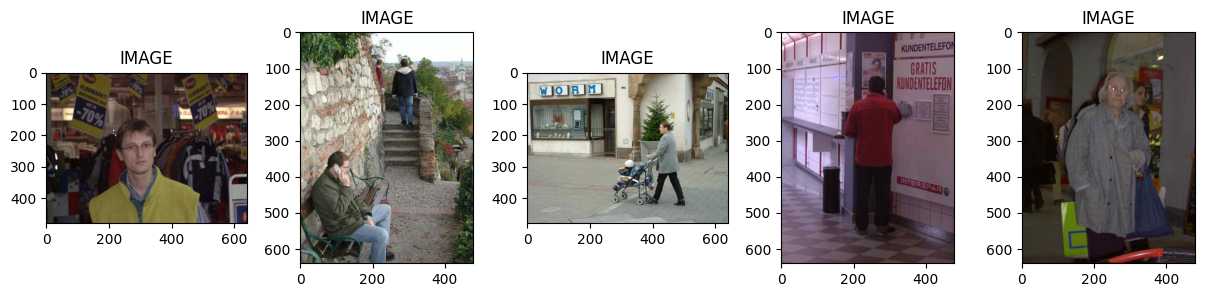

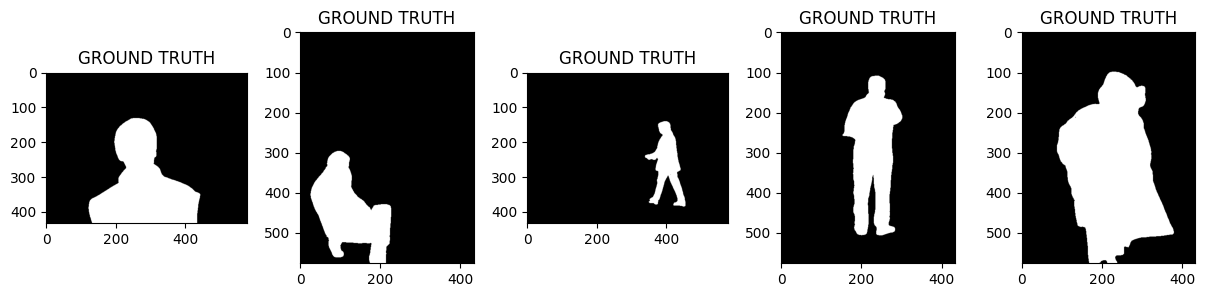

In [6]:
generate_sample_images(sample)
generate_sample_masks(sample)

In [7]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=59)
print(len(train_df), len(val_df))

232 58


In [8]:
# define the augmentations

IMG_SIZE = 320

def get_train_augs():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5)
    ], is_check_shapes=False)

def get_val_augs():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE)
    ], is_check_shapes=False)

In [9]:
# custom dataset class
class SegmentationDataset(Dataset):
    def __init__(self, df, augs):
        self.df = df
        self.augs = augs

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        sample = self.df.iloc[idx]
        image = sample.images
        mask = sample.masks

        image = cv2.imread(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask, cv2.IMREAD_GRAYSCALE)
        mask = np.expand_dims(mask, axis=-1)

        if self.augs:
            data = self.augs(image=image, mask=mask)
            image = data['image']
            mask = data['mask']

        # Transpose image dimensions in pytorch format
        # (H,W,C) -> (C,H,W)
        image = np.transpose(image, (2,0,1)).astype(np.float32)
        mask = np.transpose(mask, (2,0,1)).astype(np.float32)

        # Normalize the images and masks
        image = torch.Tensor(image) / 255.0
        mask = torch.round(torch.Tensor(mask) / 255.0)

        return image, mask

In [10]:
train_data = SegmentationDataset(train_df, get_train_augs())
val_data = SegmentationDataset(val_df, get_val_augs())

In [11]:
print(f"Size of Trainset : {len(train_data)}")
print(f"Size of Validset : {len(val_data)}")

Size of Trainset : 232
Size of Validset : 58


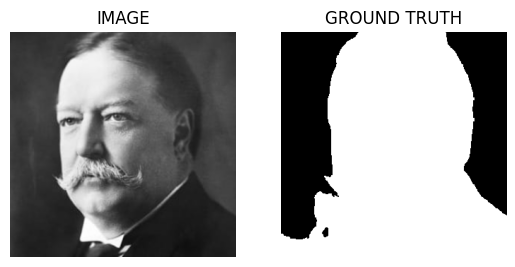

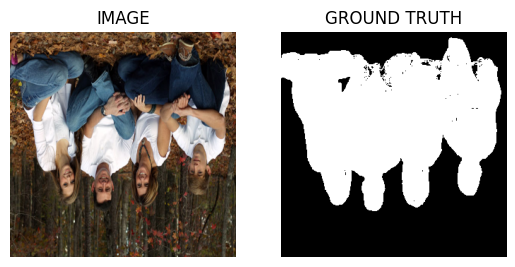

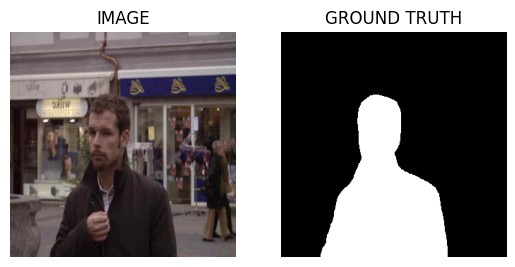

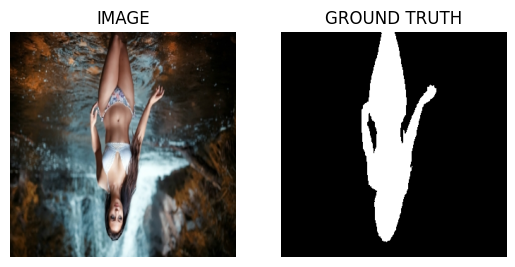

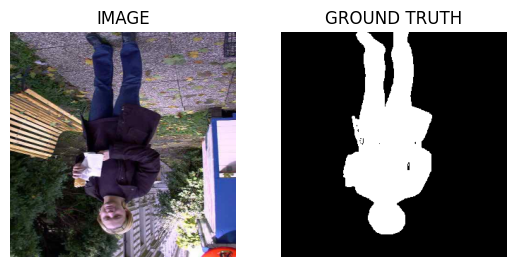

In [12]:
def processed_image(idx):
    image, mask = train_data[idx]

    plt.subplot(1,2,1)
    plt.imshow(np.transpose(image, (1,2,0)))
    plt.axis('off')
    plt.title("IMAGE");

    plt.subplot(1,2,2)
    plt.imshow(np.transpose(mask, (1,2,0)), cmap='gray')
    plt.axis('off')
    plt.title("GROUND TRUTH");
    plt.show()

for i in np.random.randint(0, len(train_data), 5):
    processed_image(i)

# Dataloader

In [13]:
BATCH_SIZE = 16

trainloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=True)

print(f"Total number of batches in Train Loader: {len(trainloader)}")
print(f"Total number of batches in Val Loader: {len(valloader)}")

Total number of batches in Train Loader: 15
Total number of batches in Val Loader: 4


In [14]:
for image, mask in trainloader:
    print(f"Size of one batch of images: {image.shape}")
    print(f"Size of one batch of masks: {mask.shape}")
    break

Size of one batch of images: torch.Size([16, 3, 320, 320])
Size of one batch of masks: torch.Size([16, 1, 320, 320])


# U-Net architecture

In [15]:

class Unet(nn.Module):

    def contract_block(self,in_ch,out_ch):


        block = nn.Sequential(
                nn.Conv2d(in_ch,out_ch,kernel_size=3,padding = 1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_ch),
                nn.Conv2d(out_ch,out_ch,kernel_size=3,padding = 1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(out_ch)
                )
        return block

    def expansive_block(self,in_ch ,mid_ch ,out_ch):

        block = nn.Sequential(
                nn.Conv2d(in_ch,mid_ch,kernel_size=3,padding = 1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(mid_ch),
                nn.Conv2d(mid_ch,mid_ch,kernel_size=3,padding = 1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(mid_ch),
                nn.ConvTranspose2d(mid_ch,out_ch,kernel_size = 3,stride = 2,padding = 1,output_padding = 1)
                )

        return block

    def final_block(self, in_ch, mid_ch , out_ch):

        block = nn.Sequential(
                nn.Conv2d(in_ch,mid_ch,kernel_size=3,padding = 1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(mid_ch),
                nn.Conv2d(mid_ch,mid_ch,kernel_size=3,padding = 1),
                nn.ReLU(inplace=True),
                nn.BatchNorm2d(mid_ch),
                nn.Conv2d(mid_ch,out_ch,kernel_size=3,padding=1)
                )
        return block


    def __init__(self,in_channel,no_classes):
        super (Unet,self).__init__()
        # encode part
        self.conv_encode1 = self.contract_block(in_ch = in_channel,out_ch = 64)
        self.downsample1 = nn.MaxPool2d(kernel_size = 2)
        self.conv_encode2 = self.contract_block(in_ch = 64 ,out_ch = 128)
        self.downsample2 = nn.MaxPool2d(kernel_size = 2)
        self.conv_encode3 = self.contract_block(in_ch = 128 ,out_ch = 256)
        self.downsample3 = nn.MaxPool2d(kernel_size = 2)
        self.conv_encode4 = self.contract_block(in_ch = 256 ,out_ch = 512)
        self.downsample4 = nn.MaxPool2d(kernel_size = 2)


        # bottle neck part
        self.bottleneck = nn.Sequential(
                          nn.Conv2d(512,1024,kernel_size=3,padding= 1),
                          nn.ReLU(inplace=True),
                          nn.BatchNorm2d(1024),
                          nn.Conv2d(1024,1024,kernel_size=3,padding = 1),
                          nn.ReLU(inplace=True),
                          nn.BatchNorm2d(1024),
                          nn.ConvTranspose2d(1024,512,kernel_size = 3,stride = 2,padding = 1,output_padding = 1)
                            )

        # decode part
        self.conv_decode4 = self.expansive_block(in_ch = 1024,mid_ch = 512 ,out_ch = 256)
        self.conv_decode3 = self.expansive_block(in_ch = 512,mid_ch = 256 ,out_ch = 128)
        self.conv_decode2 = self.expansive_block(in_ch = 256,mid_ch = 128 ,out_ch = 64)
        self.final_layer = self.final_block(in_ch = 128,mid_ch = 64 ,out_ch = no_classes)


    def crop_and_concat(self,upsampled,bypass,crop = False):
        if crop:
            c = (bypass.size()[2] - upsampled.size()[2]) // 2
            bypass = F.pad(bypass,(-c,-c,-c,-c))

        else:
            return torch.cat((upsampled,bypass),1) # concatenate along column dimension


    def forward(self,x):
            # encode

            encode_layer1 = self.conv_encode1(x)
            encode_pool1 = self.downsample1(encode_layer1)

            encode_layer2 = self.conv_encode2(encode_pool1 )
            encode_pool2 = self.downsample2(encode_layer2)

            encode_layer3 = self.conv_encode3(encode_pool2 )
            encode_pool3 = self.downsample3(encode_layer3)

            encode_layer4 = self.conv_encode4(encode_pool3 )
            encode_pool4 = self.downsample3(encode_layer4)

            # Bottleneck

            bottleneck = self.bottleneck(encode_pool4)

            # Decode
            skip_connection1 = self.crop_and_concat(bottleneck,encode_layer4,crop=False)
            decode_layer4 = self.conv_decode4(skip_connection1)

            skip_connection2 = self.crop_and_concat(decode_layer4,encode_layer3, crop=False)
            decode_layer3 = self.conv_decode3(skip_connection2)

            skip_connection3 = self.crop_and_concat(decode_layer3,encode_layer2,crop=False)
            decode_layer2 = self.conv_decode2(skip_connection3)

            skip_connection4 = self.crop_and_concat(decode_layer2,encode_layer1,crop =False)
            final_layer = self.final_layer(skip_connection4)

            return final_layer


# Training

In [16]:
class BinaryMetrics():

    def __init__(self, eps=1e-5, activation='0-1'):
        self.eps = eps
        self.activation = activation

    def _calculate_overlap_metrics(self, gt, pred):
        output = pred.view(-1, )
        target = gt.view(-1, ).float()

        tp = torch.sum(output * target)  # TP
        fp = torch.sum(output * (1 - target))  # FP
        fn = torch.sum((1 - output) * target)  # FN
        tn = torch.sum((1 - output) * (1 - target))  # TN

        pixel_acc = (tp + tn + self.eps) / (tp + tn + fp + fn + self.eps)
        dice = (2 * tp + self.eps) / (2 * tp + fp + fn + self.eps)
        precision = (tp + self.eps) / (tp + fp + self.eps)
        recall = (tp + self.eps) / (tp + fn + self.eps)
        f1 = (2 * precision * recall) / (precision + recall)
        specificity = (tn + self.eps) / (tn + fp + self.eps)

        return pixel_acc, dice, precision, specificity, recall, f1

    def __call__(self, y_true, y_pred):
        # y_true: (N, H, W)
        # y_pred: (N, 1, H, W)
        if self.activation in [None, 'none']:
            activation_fn = lambda x: x
            activated_pred = activation_fn(y_pred)
        elif self.activation == "sigmoid":
            activation_fn = nn.Sigmoid()
            activated_pred = activation_fn(y_pred)
        elif self.activation == "0-1":
            sigmoid_pred = nn.Sigmoid()(y_pred)
            activated_pred = (sigmoid_pred > 0.5).float().to(y_pred.device)
        else:
            raise NotImplementedError()

        assert activated_pred.shape[1] == 1

        pixel_acc, dice, precision, specificity, recall, f1 = self._calculate_overlap_metrics(y_true.to(y_pred.device,
                                                                                                    dtype=torch.float),
                                                                                          activated_pred)
        return {'pixel_acc':pixel_acc.cpu().numpy(),
                'dice_score':dice.cpu().numpy(),
                'precision': precision.cpu().numpy(),
                'recall': recall.cpu().numpy(),
                'f1': f1.cpu().numpy(),
                'specificity':specificity.cpu().numpy(),
                }

In [18]:

train_losses, val_losses = [], []
val_metrics = []

def train_val(dataloaders,model,criterion,optimizer,num_epochs,log_dir,bin_metrics,device):
    """
    training and validation function phase for each epoch
    Args:
    log_dir(str): mention the path to save the logfiles
    """
    num_images = 0
    best_f1 = 0

    for epoch in range(num_epochs):

        since = time.time()
        running_loss = 0.0
        # Each epoch has a training and validation phase
        for phase in ["train","val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
            # define metric variables
            running_loss = 0.0
            total_train = 0
            correct_train = 0
            #iterate over the data
            for index, sampled_batch in enumerate(dataloaders[phase]):
                image, mask = sampled_batch
                inputs = image.to(device)  # N,C,H,W
                labels = mask  # N,C,H.W
                labels = torch.squeeze(labels,1).long().to(device) # N,H,W
                num_images += inputs.size(0)

                optimizer.zero_grad()
                #forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _,predicted = torch.max(outputs, 1, keepdim=True) # N,1,H,W
                    loss = criterion(outputs,labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                #metric evaluation
                running_loss += loss.item()

            epoch_loss =  running_loss / num_images
            metrics_dict = bin_metrics(labels, predicted)

            if phase == 'train':
              train_losses.append(epoch_loss)
            else:
              val_metrics.append(metrics_dict)
              val_losses.append(epoch_loss)

            if epoch % 10 == 0:
              if phase == 'train':
                print("{} --- Epoch {}, Epoch train loss : {:.7f} , Pixel accuracy : {}".format(phase, epoch, epoch_loss, metrics_dict['pixel_acc']))
              else:
                print("{} --- Epoch {}, Epoch Val loss : {:.7f} , Pixel accuracy : {} , Precision : {}, Recall : {}, F1 : {}, Dice score : {}".
                      format(phase, epoch, epoch_loss, metrics_dict['pixel_acc'], metrics_dict['precision'],metrics_dict['recall'], metrics_dict['f1'], metrics_dict['dice_score']))

            # saving the model
            if phase == "val" and metrics_dict['f1'] > best_f1:
                best_f1 = metrics_dict['f1']
                torch.save({ "epoch": epoch,
                            "model_state_dict":model.state_dict(),
                            "optimizer_state_dict":optimizer.state_dict(),
                            "loss":epoch_loss,
                        },(os.path.join(log_dir,'train_exp-epoch{}.pth'.format(epoch))))
            else:
                pass

            time_elapsed = time.time()-since


In [20]:

dataloaders = {'train':trainloader, 'val':valloader}
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
save_dir = '/content/checkpoints'

num_epochs = 100
LR = 0.001
bin_metrics = BinaryMetrics()
model = Unet(3, 2)
model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),
                      lr=LR,
                      momentum=0.9,
                      weight_decay=0.0005)

train_val(dataloaders, model, criterion, optimizer, num_epochs, save_dir, bin_metrics, DEVICE)

train --- Epoch 0, Epoch train loss : 0.0441904 , Pixel accuracy : 0.6422656178474426
val --- Epoch 0, Epoch Val loss : 0.0088188 , Pixel accuracy : 0.7021299004554749 , Precision : 0.32751092314720154, Recall : 0.0002459500392433256, F1 : 0.000491530925501138, Dice score : 0.0004915309837087989
train --- Epoch 10, Epoch train loss : 0.0023231 , Pixel accuracy : 0.8299035429954529
val --- Epoch 10, Epoch Val loss : 0.0006388 , Pixel accuracy : 0.7444804906845093 , Precision : 0.4925509989261627, Recall : 0.4329345226287842, F1 : 0.4608226418495178, Dice score : 0.46082261204719543
train --- Epoch 20, Epoch train loss : 0.0010819 , Pixel accuracy : 0.8303283452987671
val --- Epoch 20, Epoch Val loss : 0.0003183 , Pixel accuracy : 0.8356025218963623 , Precision : 0.7314872741699219, Recall : 0.737218976020813, F1 : 0.7343419194221497, Dice score : 0.7343419194221497
train --- Epoch 30, Epoch train loss : 0.0006649 , Pixel accuracy : 0.7735949754714966
val --- Epoch 30, Epoch Val loss : 0

In [33]:
def plot_losses(train_losses, val_losses):
  fig = plt.figure(figsize=(8, 6))
  ax = plt.gca()
  ax.set_ylim([0, 0.04])

  idxs = [i for i in range(len(train_losses))]
  plt.plot(idxs, train_losses, label='train')
  plt.plot(idxs, val_losses, label='val')
  plt.title('train/val loss')
  plt.xlabel('epochs')
  plt.ylabel('ce loss')
  plt.legend()


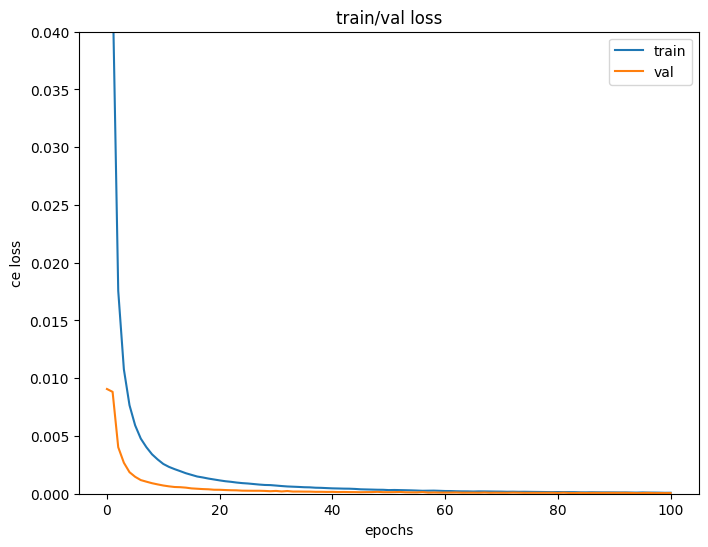

In [34]:
# mb my loss choise isn't the best one

plot_losses(train_losses, val_losses)

In [46]:

def plot_val_metrics(val_metrics_dict):

  accs = [data['pixel_acc'] for data in val_metrics_dict]
  f1s = [data['f1'] for data in val_metrics_dict]
  dicesс = [data['dice_score'] for data in val_metrics_dict]

  idxs = [i for i in range(len(val_metrics_dict))]

  fig, axes = plt.subplots(3, figsize=(10, 14))

  axes[0].plot(idxs, accs, label='accuracy')
  axes[0].set_title('acc dynamic')
  axes[0].set_xlabel('epochs')
  axes[0].set_ylabel('accuracy')

  axes[1].plot(idxs, f1s, label='f1_score')
  axes[1].set_title('f1 dynamic')
  axes[1].set_xlabel('epochs')
  axes[1].set_ylabel('f1')

  axes[2].plot(idxs, dicesс, label='dice_score')
  axes[2].set_title('dice dynamic')
  axes[2].set_xlabel('epochs')
  axes[2].set_ylabel('dice')


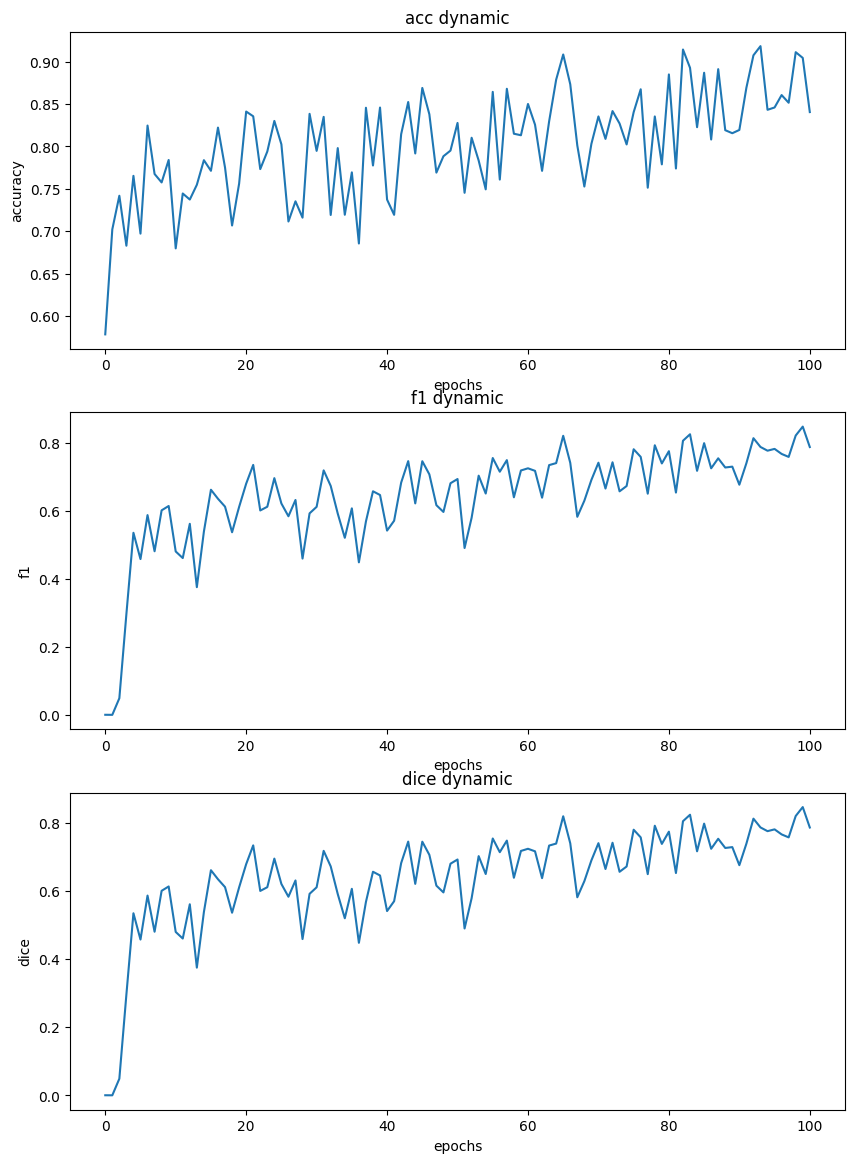

In [48]:
# amount of data is smoll and also some labels aren't very high quality
# so looks a bit spiky, but still positive growth for all metrics on validation

plot_val_metrics(val_metrics)

# Inference

In [16]:
#logs_path = '/content/checkpoints/train_exp-epoch98.pth'
logs_path = '/content/train_exp-epoch98.pth'

model = Unet(3, 2)
checkpoint = torch.load(logs_path, map_location=torch.device('cpu'))
model.load_state_dict(checkpoint["model_state_dict"])


<ipython-input-16-a6be25105fad>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(logs_path, map_location=torch.device('cpu'))


<All keys matched successfully>

In [17]:

for index, sampled_batch in enumerate(valloader):
  images, masks = sampled_batch
  break

DEVICE = 'cpu'
inputs = images  # N,C,H,W
labels = masks  # N,C,H,W

outputs = model(inputs)
_, predicted = torch.max(outputs, 1, keepdims=True)

print(predicted.shape, labels.shape)

torch.Size([16, 1, 320, 320]) torch.Size([16, 1, 320, 320])


In [20]:
# 57 seconds for 16 images, ~3500 ms for one image

In [21]:
def plot_preds(images, masks, preds):

    assert preds.shape == masks.shape

    print(images.shape)
    for i in range(preds.shape[0]):
      plt.figure(figsize=(10, 3))
      plt.subplot(1,3,1)
      plt.imshow(np.transpose(images[i], (1,2,0)))
      plt.axis('off')
      plt.title('image')

      plt.subplot(1,3,2)
      plt.imshow(np.transpose(masks[i], (1,2,0)), cmap='gray')
      plt.axis('off')
      plt.title('gt')

      plt.subplot(1,3,3)
      plt.imshow(np.transpose(preds[i], (1,2,0)), cmap='gray')
      plt.axis('off')
      plt.title('preds')



torch.Size([16, 3, 320, 320])


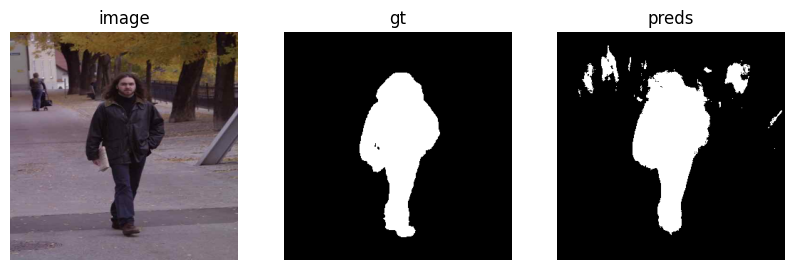

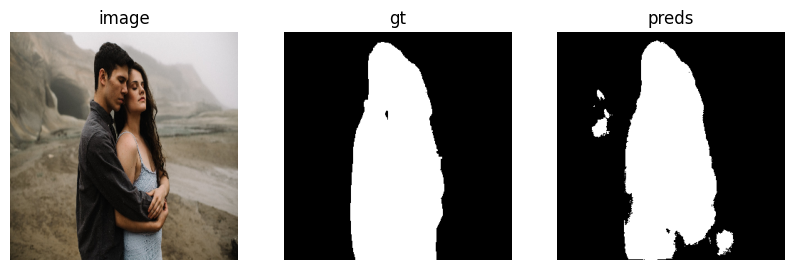

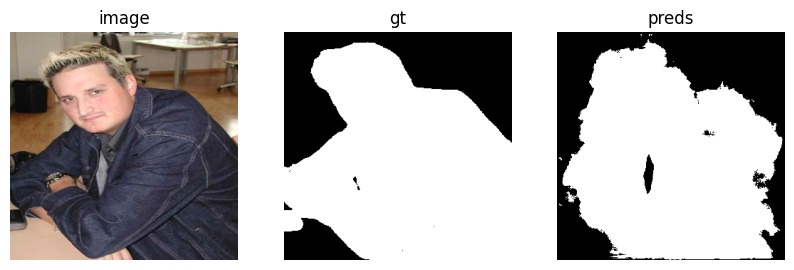

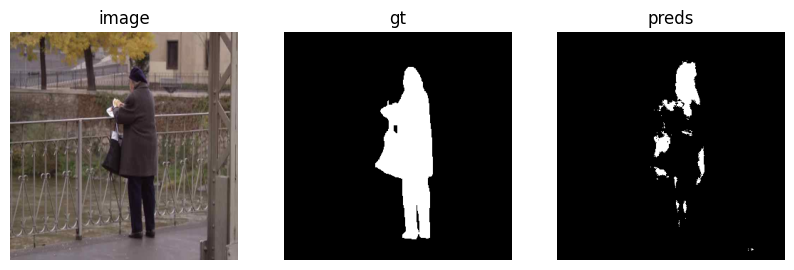

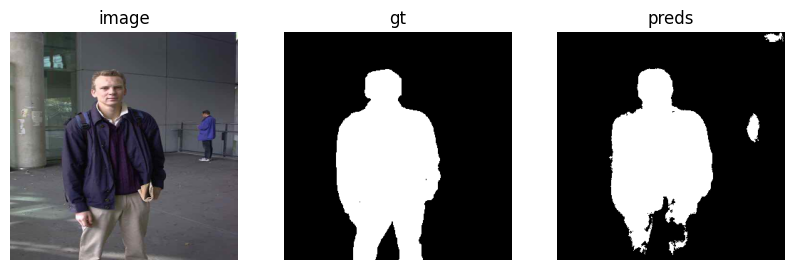

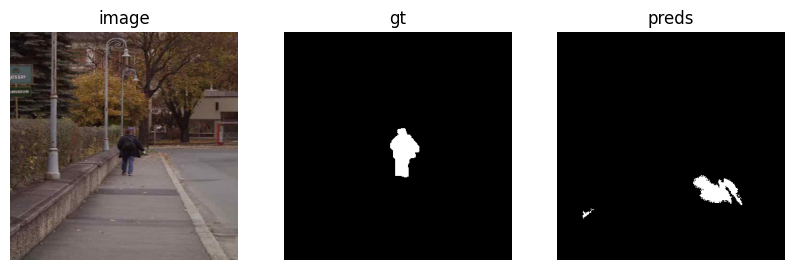

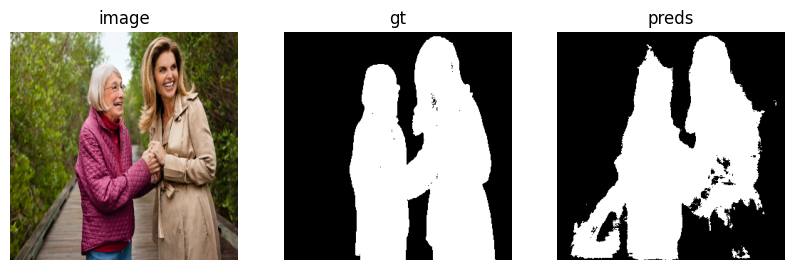

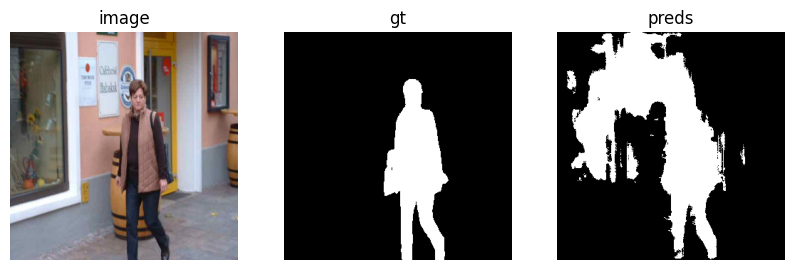

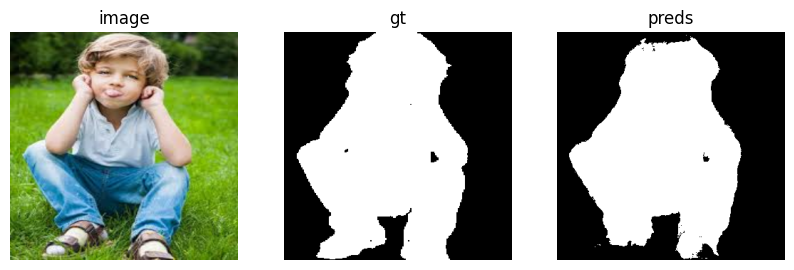

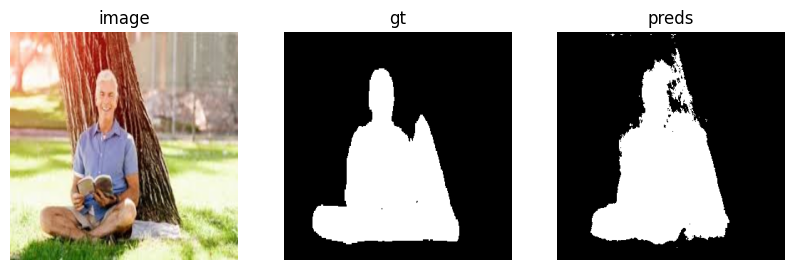

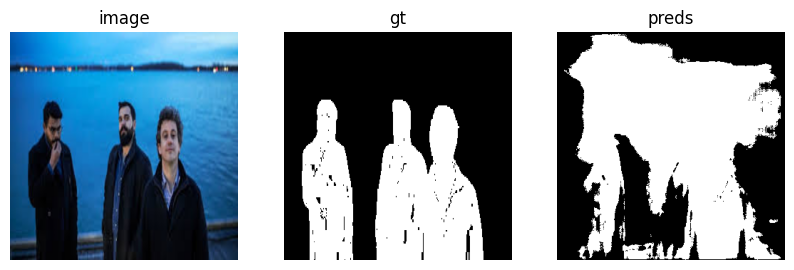

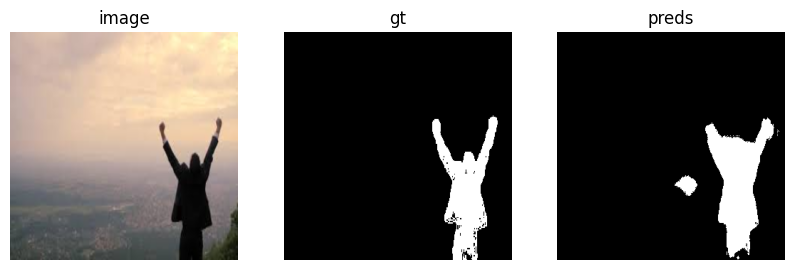

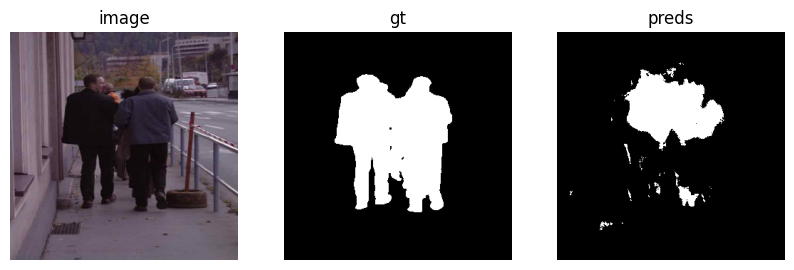

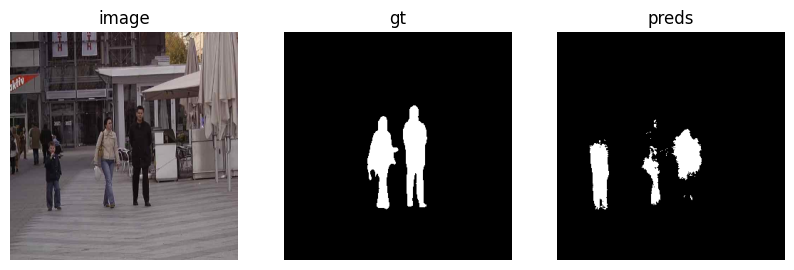

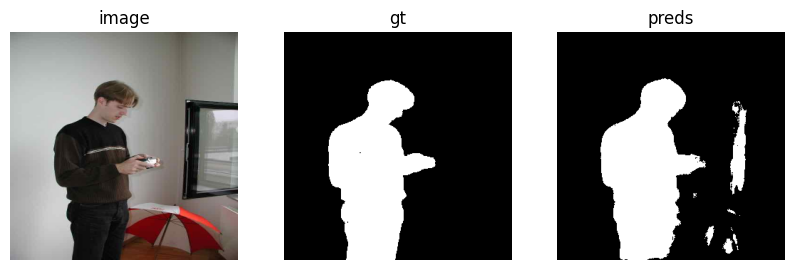

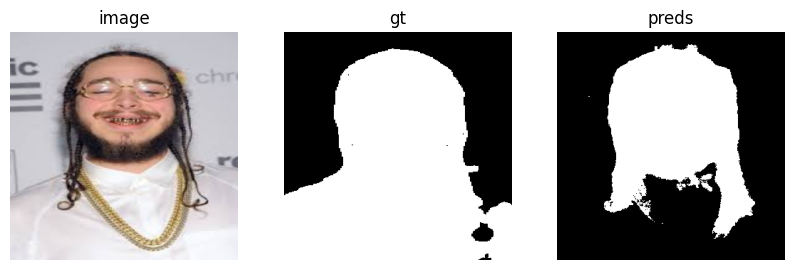

In [22]:
# could be better with different loss I think, will retrain it when colab gives me gpu

plot_preds(images, labels, predicted)